In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import json
import seaborn as sns
from pathlib import Path
plt.rc('font', family='Malgun Gothic')

In [7]:
from eda.lib import load_data

# df = load_data(json_path="/path/to/other/data.json")
df = load_data()

# 범죄율
df['crime_rate'] = df['crime']/ df['population'] * 10000
# 버거지수
df['burger_ind'] = (df['burgerking'] + df['mcdonalds'] + df['kfc']) / df['lotteria']
df['burger_ind'] = df.apply(lambda row: 0 if row['lotteria'] == 0 else row['burger_ind'], axis=1)
df.head()

,sido,sigungu,population,crime,violence,burgerking,lotteria,mcdonalds,kfc,crime_rate,burger_ind
0,서울,강남구,557345,17235,4012,9,7,9,8,309.233957,3.714286
1,서울,강동구,476942,5328,1697,4,8,3,3,111.711697,1.250000
2,서울,강북구,283597,4264,1320,3,5,4,2,150.354200,1.800000
3,서울,강서구,556171,7727,2337,7,12,4,4,138.932091,1.250000
4,서울,관악구,477812,8651,2520,6,9,1,3,181.054473,1.111111


C:\Users\Playdata\AppData\Local\Temp\ipykernel_13960\1534886476.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('crime_rate_bin')['burger_ind'].mean()


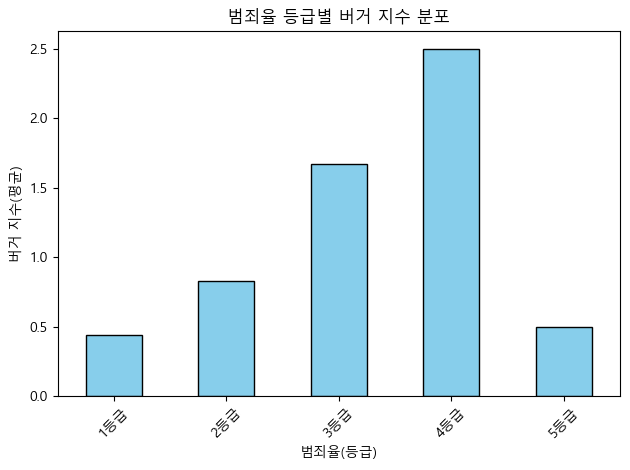

In [8]:
# crime rate 를 구간으로 나누고 각 구간별로 burger ind 의 평균을 그래프로

# crime_rate를 5개 구간으로 나누기
labels = ['1등급', '2등급', '3등급', '4등급', '5등급']
df['crime_rate_bin'] = pd.cut(df['crime_rate'], bins=5, labels=labels)

# 각 구간별 burger_ind 평균 계산
grouped = df.groupby('crime_rate_bin')['burger_ind'].mean()

# 히스토그램 그리기
grouped.plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel('범죄율(등급)')
plt.ylabel('버거 지수(평균)')
plt.title('범죄율 등급별 버거 지수 분포')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [9]:
# 범죄율 등급 구분: 사분위
def crime_grade(score):
    if score > 158:
        return '4등급'
    if score > 136.5:
        return '3등급'
    if score > 116.3:
        return '2등급'
    else:
        return '1등급'

df['crime_gd'] = df['crime_rate'].apply(crime_grade)

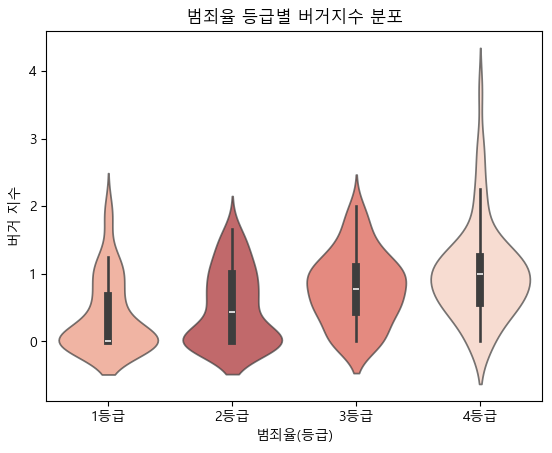

In [10]:
# 범죄율 등급별 버거지수 분포 - 바이올린 차트
sns.violinplot(x='crime_gd', y='burger_ind', data=df, order=['1등급', '2등급', '3등급', '4등급'], palette='Reds', alpha= 0.7, hue='crime_gd')
plt.xlabel('범죄율(등급)')
plt.ylabel('버거 지수')
plt.title('범죄율 등급별 버거지수 분포')
plt.show()

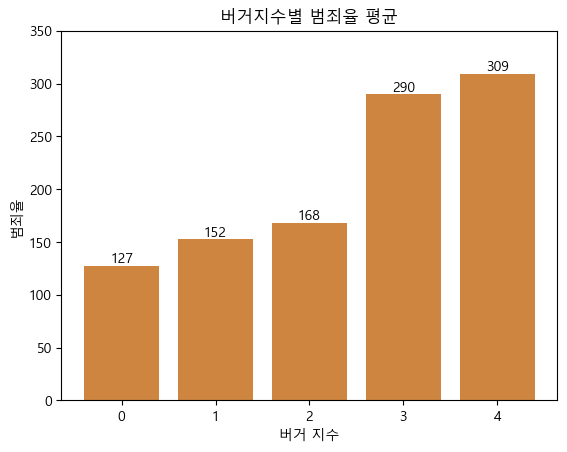

In [11]:
# 버거지수 반올림
df.loc[:, 'burger_ind'] = df['burger_ind'].round().astype(int)

# 버거지수를 기준으로 범죄율 평균을 보는 그래프
crime_rate_grp = df.groupby('burger_ind')['crime_rate'].mean().reset_index()

graph = plt.bar(crime_rate_grp['burger_ind'], crime_rate_grp['crime_rate'], color='peru')
plt.ylim(0,350)

# 데이터 값 표시
for rate_value in graph:
    height = rate_value.get_height()
    plt.text(rate_value.get_x() + rate_value.get_width()/2.0, height, '%i' % height, ha='center', va='bottom', size=10)

plt.ylabel('범죄율')
plt.xlabel('버거 지수')
plt.title('버거지수별 범죄율 평균')
plt.show()